# Exercise 3

## Imports

In [36]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import transform
from rasterio.crs import CRS
from rasterio.windows import Window
from rasterio.warp import transform_bounds
import spectral.io.envi as envi
from pyproj import Transformer
from pystac_client import Client
import planetary_computer
from datetime import datetime

ACQUISITION_DATE = '2025-06-17'
SCALE_FACTOR = 10000.0
# do not read reflectance above this value
IGNORE_VALUE = 15000.0
# lots of problems without this one...
EPSG_LOCAL = 2177 

# from root dir
BASE_DIR = Path().cwd() / "lab_5" / "data" / "you-shall-not-pass" / "Obrazy lotnicze"
hdr_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'
bsq_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.bsq'

def find_band(target_nm, wavelengths):
    """Return the 0-based band index closest to target_nm."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))

def read_reflectance(img, band_idx, subregion=None):
    """Read a band; apply mask & scale to fractional reflectance."""
    if subregion:
        data = img.read_subregion(subregion[0], subregion[1], bands=[band_idx]).squeeze().astype(np.float32)
    else:
        data = img.read_bands([band_idx]).squeeze().astype(np.float32)
    data = np.where((data >= IGNORE_VALUE) | (data < 0), np.nan, data)
    return data / SCALE_FACTOR

print(f"Target Date: {ACQUISITION_DATE}")
print(f"Airborne Data Path: {bsq_path}")

Target Date: 2025-06-17
Airborne Data Path: E:\github_repos\eolabs\lab_5\data\you-shall-not-pass\Obrazy lotnicze\221000_Odra_HS_Blok_A_008_VS_join_atm.bsq


## Load Airborne data

In [ ]:
if not hdr_path.exists():
    raise FileNotFoundError(f"Cannot find airborne data at {hdr_path}")

img = envi.open(hdr_path)
meta = img.metadata
wavelengths = np.array([float(x) for x in meta['wavelength']])

# Read a subset (1000x1000) from the center to keep memory usage low
cy, cx = img.nrows // 2, img.ncols // 2
row_range = (cy-500, cy+500)
col_range = (cx-500, cx+500)


# without it it might be harder to compare water analysis - land might generate noise
def make_water_mask(img, wavelengths, subregion, nir_nm=780, green_nm=560, nir_threshold=0.05):
    """Returns boolean mask: True = water pixel."""
    nir = read_reflectance(img, find_band(nir_nm, wavelengths), subregion)
    green = read_reflectance(img, find_band(green_nm, wavelengths), subregion)
    
    ndwi = (green - nir) / (green + nir + 1e-9)
    mask = (nir < nir_threshold) & (ndwi > 0) & np.isfinite(nir)
    return mask


def stretch(arr, pct=(2, 98)):
    lo, hi = np.nanpercentile(arr, pct)
    return np.clip((arr - lo) / max(hi - lo, 1e-9), 0, 1)


water_mask = make_water_mask(img, wavelengths, (row_range, col_range))

# Extract geographic bounds of the subset using the .bsq file for rasterio
with rasterio.open(bsq_path) as src:
    air_win = Window(cx-500, cy-500, 1000, 1000)
    air_left, air_bottom, air_right, air_top = src.window_bounds(air_win)
    lons, lats = transform(src.crs, 'EPSG:4326', [air_left, air_right], [air_bottom, air_top])
    subset_bbox = [lons[0], lats[0], lons[1], lats[1]]

    

print(f"Subset water pixels: {water_mask.sum()} ({water_mask.mean()*100:.1f}%)")

Subset water pixels: 82835 (8.3%)


#### Show water mask visually

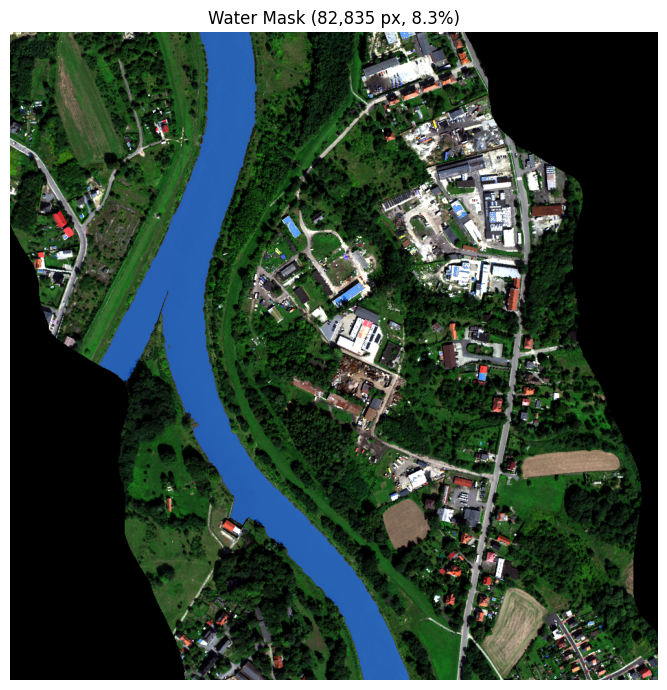

## Show false-color 

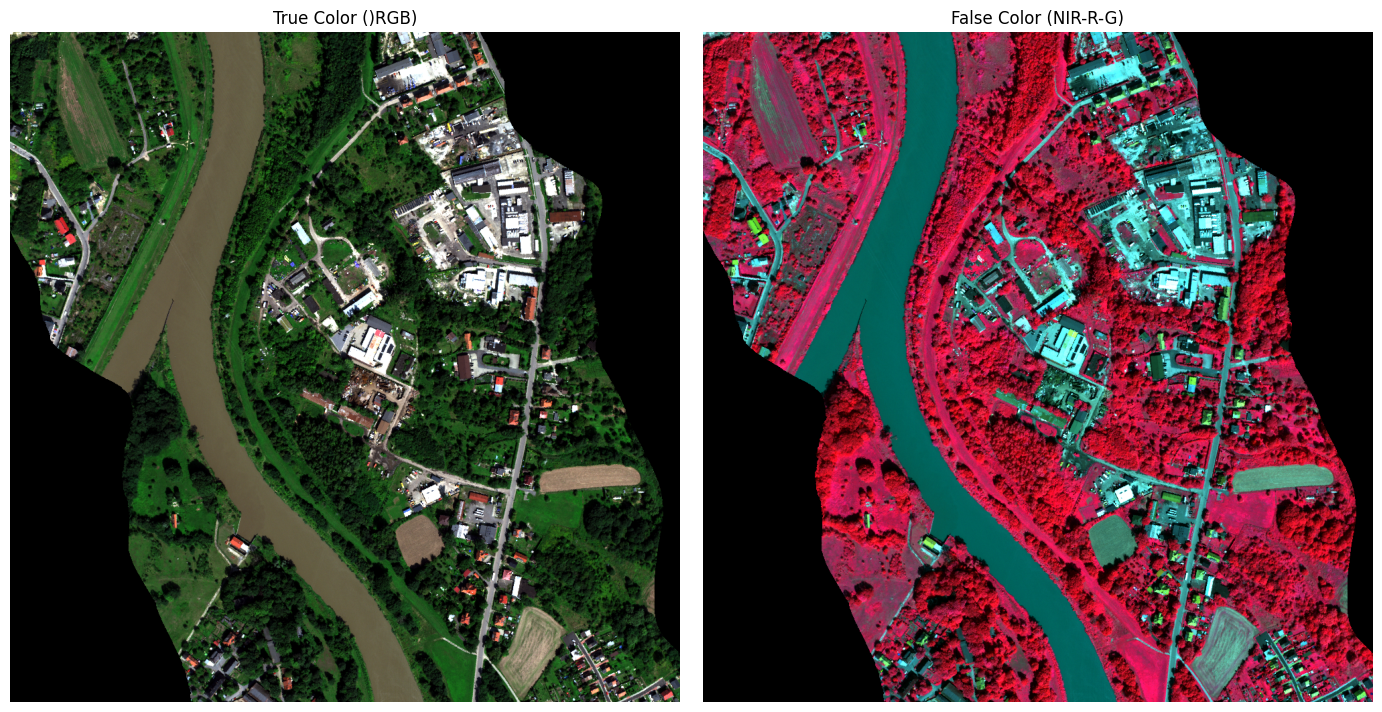

In [59]:
# TRUE COLOR
r = read_reflectance(img, find_band(660, wavelengths), (row_range, col_range))
g = read_reflectance(img, find_band(560, wavelengths), (row_range, col_range))
b = read_reflectance(img, find_band(490, wavelengths), (row_range, col_range))

rgb_true = np.dstack([stretch(r), stretch(g), stretch(b)])


# FALSE COLOR (NIR-RED-GREEN)
nir = read_reflectance(img, find_band(858, wavelengths), (row_range, col_range))
red = read_reflectance(img, find_band(660, wavelengths), (row_range, col_range))
green = read_reflectance(img, find_band(560, wavelengths), (row_range, col_range))

rgb_false = np.dstack([stretch(nir), stretch(red), stretch(green)])


fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(np.nan_to_num(rgb_true))
axes[0].set_title("True Color ()RGB)")
axes[0].axis("off")

axes[1].imshow(np.nan_to_num(rgb_false))
axes[1].set_title("False Color (NIR-R-G)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Show water mask visually

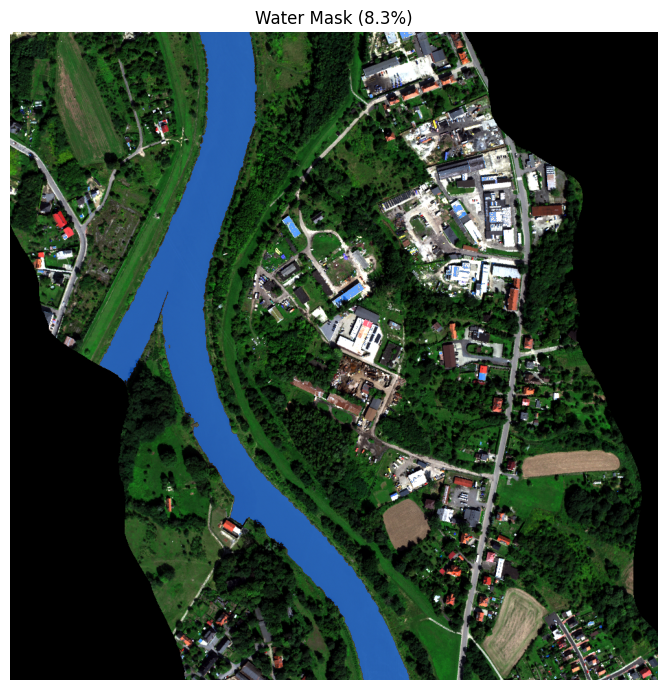

In [61]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(np.nan_to_num(rgb_true))
water_overlay = np.zeros((*water_mask.shape, 4))
water_overlay[water_mask] = [0, 0.4, 1, 0.6]
ax.imshow(water_overlay)
ax.set_title(f"Water Mask ({water_mask.mean()*100:.1f}%)")
ax.axis("off")

plt.tight_layout()
plt.show()

## Water Quality Indices: Technical Notes

The following indices are used to estimate water constituents from spectral reflectance:

1. **Chlorophyll-a (Chl-a)**: This is the primary pigment found in phytoplankton. In water quality monitoring, it serves as a proxy for algal biomass and eutrophication. We use the **Red Edge/Red ratio (705nm / 665nm)**. This ratio is effective because 665nm corresponds to a chlorophyll absorption peak, while 705nm (the "red edge") is highly reflective for vegetation/algae, making the ratio sensitive to concentration changes.

2. **Dissolved Organic Carbon (DOC)**: Often measured via CDOM (Chromophoric Dissolved Organic Matter), this represents organic material that stains the water. We use the **Green/Red ratio (560nm / 665nm)**. DOC strongly absorbs blue and green light; by comparing the green reflectance to the red, we can estimate the concentration of these dissolved components.

3. **Turbidity**: This measures water clarity and the presence of suspended particulate matter (sediment, silt, or organic debris). 
    - In the **airborne** data, we use reflectance at **700nm**, where the signal is dominated by backscatter from suspended solids.
    - In **Sentinel-2**, we use the **B11 (SWIR)** band as a proxy. Since water strongly absorbs SWIR radiation, any reflectance in this band typically indicates the presence of suspended matter or surface floating material.

## Water Quality Indices (Airborne)

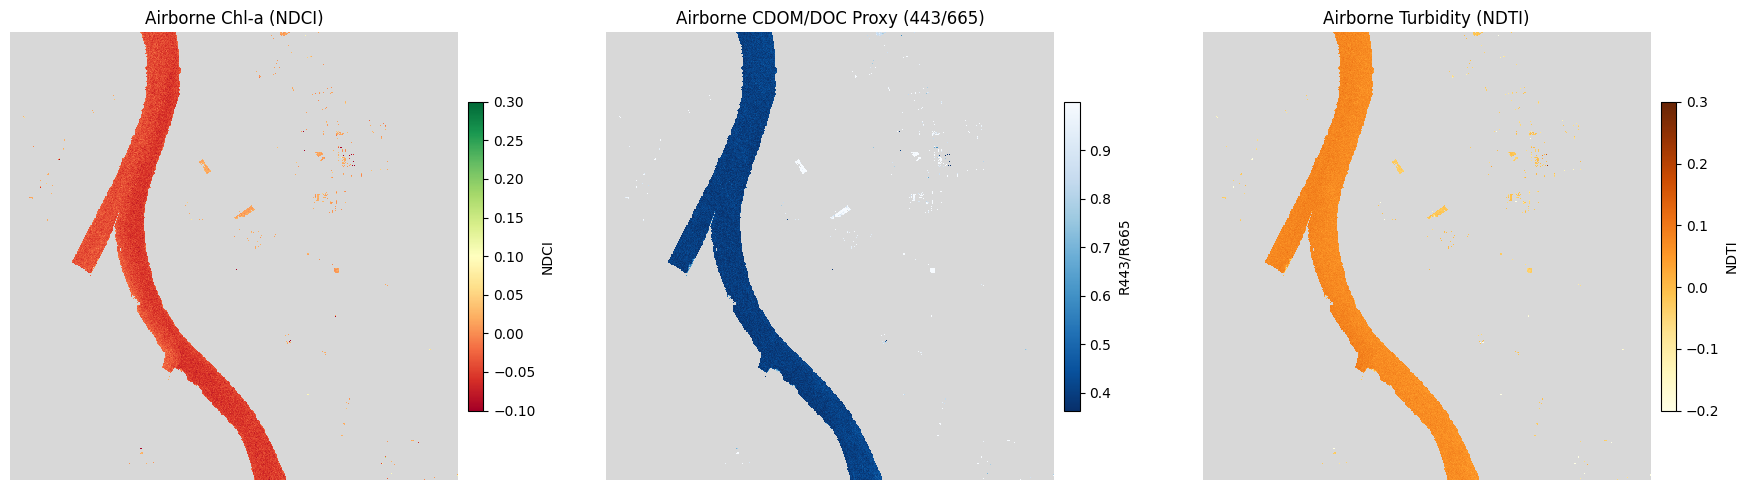

In [ ]:
R443 = read_reflectance(img, find_band(443, wavelengths), (row_range, col_range))
R560 = read_reflectance(img, find_band(560, wavelengths), (row_range, col_range))
R665 = read_reflectance(img, find_band(665, wavelengths), (row_range, col_range))
R709 = read_reflectance(img, find_band(709, wavelengths), (row_range, col_range))

# epsilon for zero division avoidance
# Chl-a NDCI
chla_air = (R709 - R665) / (R709 + R665 + 1e-9)

# CDOM / DOC proxy (Blue/Red ratio)
doc_air = R443 / (R665 + 1e-9)

# Turbidity NDTI
turb_air = (R665 - R560) / (R665 + R560 + 1e-9)

def plot_index(ax, data, mask, title, cmap='RdYlGn', vmin=None, vmax=None, clabel=''):
    display = np.where(mask, data, np.nan)
    if vmin is None: vmin = np.nanpercentile(display, 2)
    if vmax is None: vmax = np.nanpercentile(display, 98)
    bg = np.ones((*mask.shape, 3)) * 0.85
    ax.imshow(bg)
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=clabel)
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_index(axes[0], chla_air, water_mask, "Airborne Chl-a (NDCI)", 'RdYlGn', -0.1, 0.3, 'NDCI')
plot_index(axes[1], doc_air, water_mask, "Airborne CDOM/DOC Proxy (443/665)", 'Blues_r', clabel='R443/R665')
plot_index(axes[2], turb_air, water_mask, "Airborne Turbidity (NDTI)", 'YlOrBr', -0.2, 0.3, 'NDTI')
plt.tight_layout()
plt.show()

In [13]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

## Download Sentinel-2 Data + loading bands
dates around **2025-06-17**

In [56]:
from datetime import timedelta
acq_date = datetime.strptime(ACQUISITION_DATE, '%Y-%m-%d')
date_start = (acq_date - timedelta(days=7)).strftime('%Y-%m-%d')
date_end = (acq_date + timedelta(days=7)).strftime('%Y-%m-%d')

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=subset_bbox,
    datetime=f"{date_start}/{date_end}",
    query={"eo:cloud_cover": {"lt": 10}}
)

items = list(search.items())
if not items:
    raise ValueError("No suitable cloud-free Sentinel-2 imagery found.")

best_item = min(items, key=lambda it: abs((it.datetime.replace(tzinfo=None) - acq_date).days))
print(f"Selected Sentinel-2 Scene: {best_item.id} ({best_item.datetime.date()})")
print(f"Cloud Cover: {best_item.properties['eo:cloud_cover']:.2f}%")

assets = best_item.assets
S2_BANDS = ['B02', 'B03', 'B04', 'B05', 'B08', 'SCL']
data_s2 = {}

with rasterio.open(assets['B04'].href) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    minx, miny, maxx, maxy = transform_bounds(
        "EPSG:4326",
        src.crs,
        *subset_bbox
    )
    s2_win = src.window(minx, miny, maxx, maxy)
    s2_prof = {'crs': src.crs, 'transform': src.window_transform(s2_win), 
               'width': int(s2_win.width), 'height': int(s2_win.height)}

for b in S2_BANDS:
    with rasterio.open(assets[b].href) as src:
        data_s2[b] = src.read(1, window=s2_win, out_shape=(s2_prof['height'], s2_prof['width']), 
                              resampling=rasterio.enums.Resampling.bilinear).astype(float)
        if b != 'SCL':
            data_s2[b] = np.where(data_s2[b] == 0, np.nan, data_s2[b] / 10000.0)

Selected Sentinel-2 Scene: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401 (2025-06-15)
Cloud Cover: 0.46%


2 days off with cloud cover 0.46% - quite fine

## Water quality indices for Sentinel 2

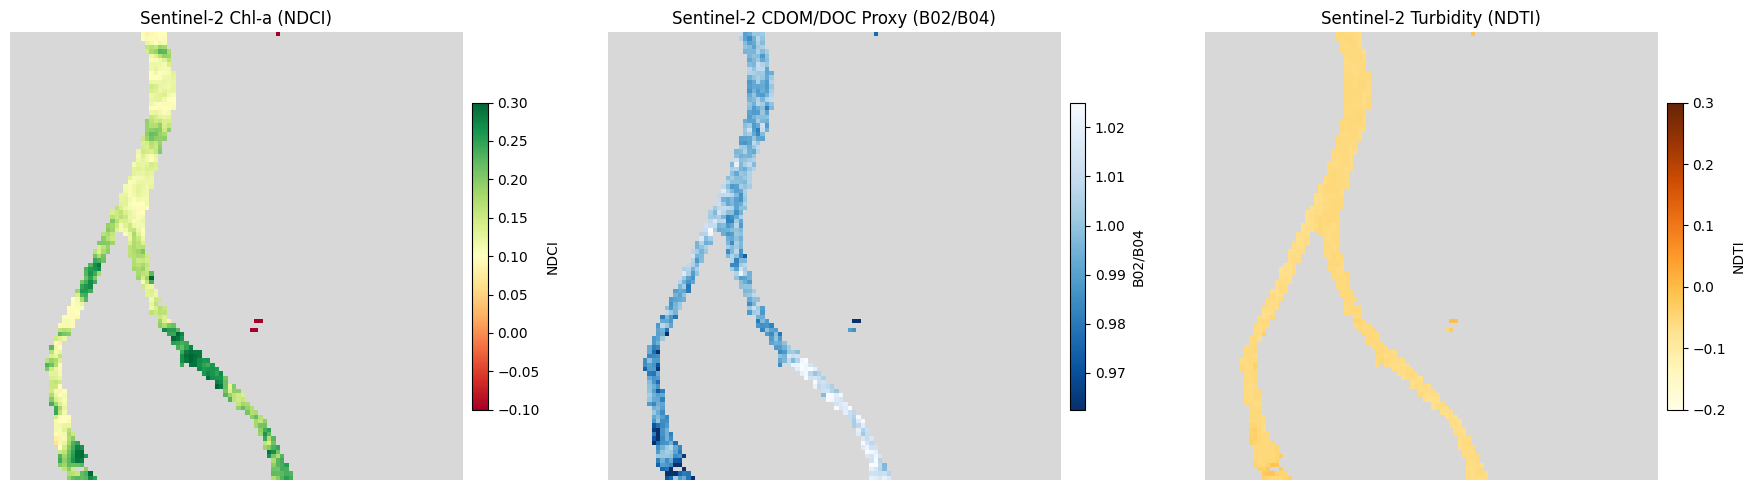

In [53]:
B02 = data_s2['B02']
B03 = data_s2['B03']
B04 = data_s2['B04']
B05 = data_s2['B05']
B08 = data_s2['B08']
SCL = data_s2['SCL']

# Sentinel-2 Water Mask
ndwi_s2 = (B03 - B08) / (B03 + B08 + 1e-9)
s2_water_mask = (SCL == 6) | (ndwi_s2 > 0)
s2_water_mask &= np.isfinite(B04)

# Indices
chla_s2 = (B05 - B04) / (B05 + B04 + 1e-9)
doc_s2 = B02 / (B04 + 1e-9)
turb_s2 = (B04 - B03) / (B04 + B03 + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_index(axes[0], chla_s2, s2_water_mask, "Sentinel-2 Chl-a (NDCI)", 'RdYlGn', -0.1, 0.3, 'NDCI')
plot_index(axes[1], doc_s2, s2_water_mask, "Sentinel-2 CDOM/DOC Proxy (B02/B04)", 'Blues_r', clabel='B02/B04')
plot_index(axes[2], turb_s2, s2_water_mask, "Sentinel-2 Turbidity (NDTI)", 'YlOrBr', -0.2, 0.3, 'NDTI')
plt.tight_layout()
plt.show()

## Compare indices

In [54]:
print(f"Airborne Chl-a Mean (Water): {np.nanmean(np.where(water_mask, chla_air, np.nan)):.4f}")
print(f"Sentinel-2 Chl-a Mean (Water): {np.nanmean(np.where(s2_water_mask, chla_s2, np.nan)):.4f}")

print(f"Airborne DOC Mean (Water): {np.nanmean(np.where(water_mask, doc_air, np.nan)):.4f}")
print(f"Sentinel-2 DOC Mean (Water): {np.nanmean(np.where(s2_water_mask, doc_s2, np.nan)):.4f}")

print(f"Airborne Turbidity Mean (Water): {np.nanmean(np.where(water_mask, turb_air, np.nan)):.4f}")
print(f"Sentinel-2 Turbidity Mean (Water): {np.nanmean(np.where(s2_water_mask, turb_s2, np.nan)):.4f}")

Airborne Chl-a Mean (Water): -0.0454
Sentinel-2 Chl-a Mean (Water): 0.1616
Airborne DOC Mean (Water): 0.4249
Sentinel-2 DOC Mean (Water): 0.9973
Airborne Turbidity Mean (Water): 0.0684
Sentinel-2 Turbidity Mean (Water): -0.0578


## Visual comparison

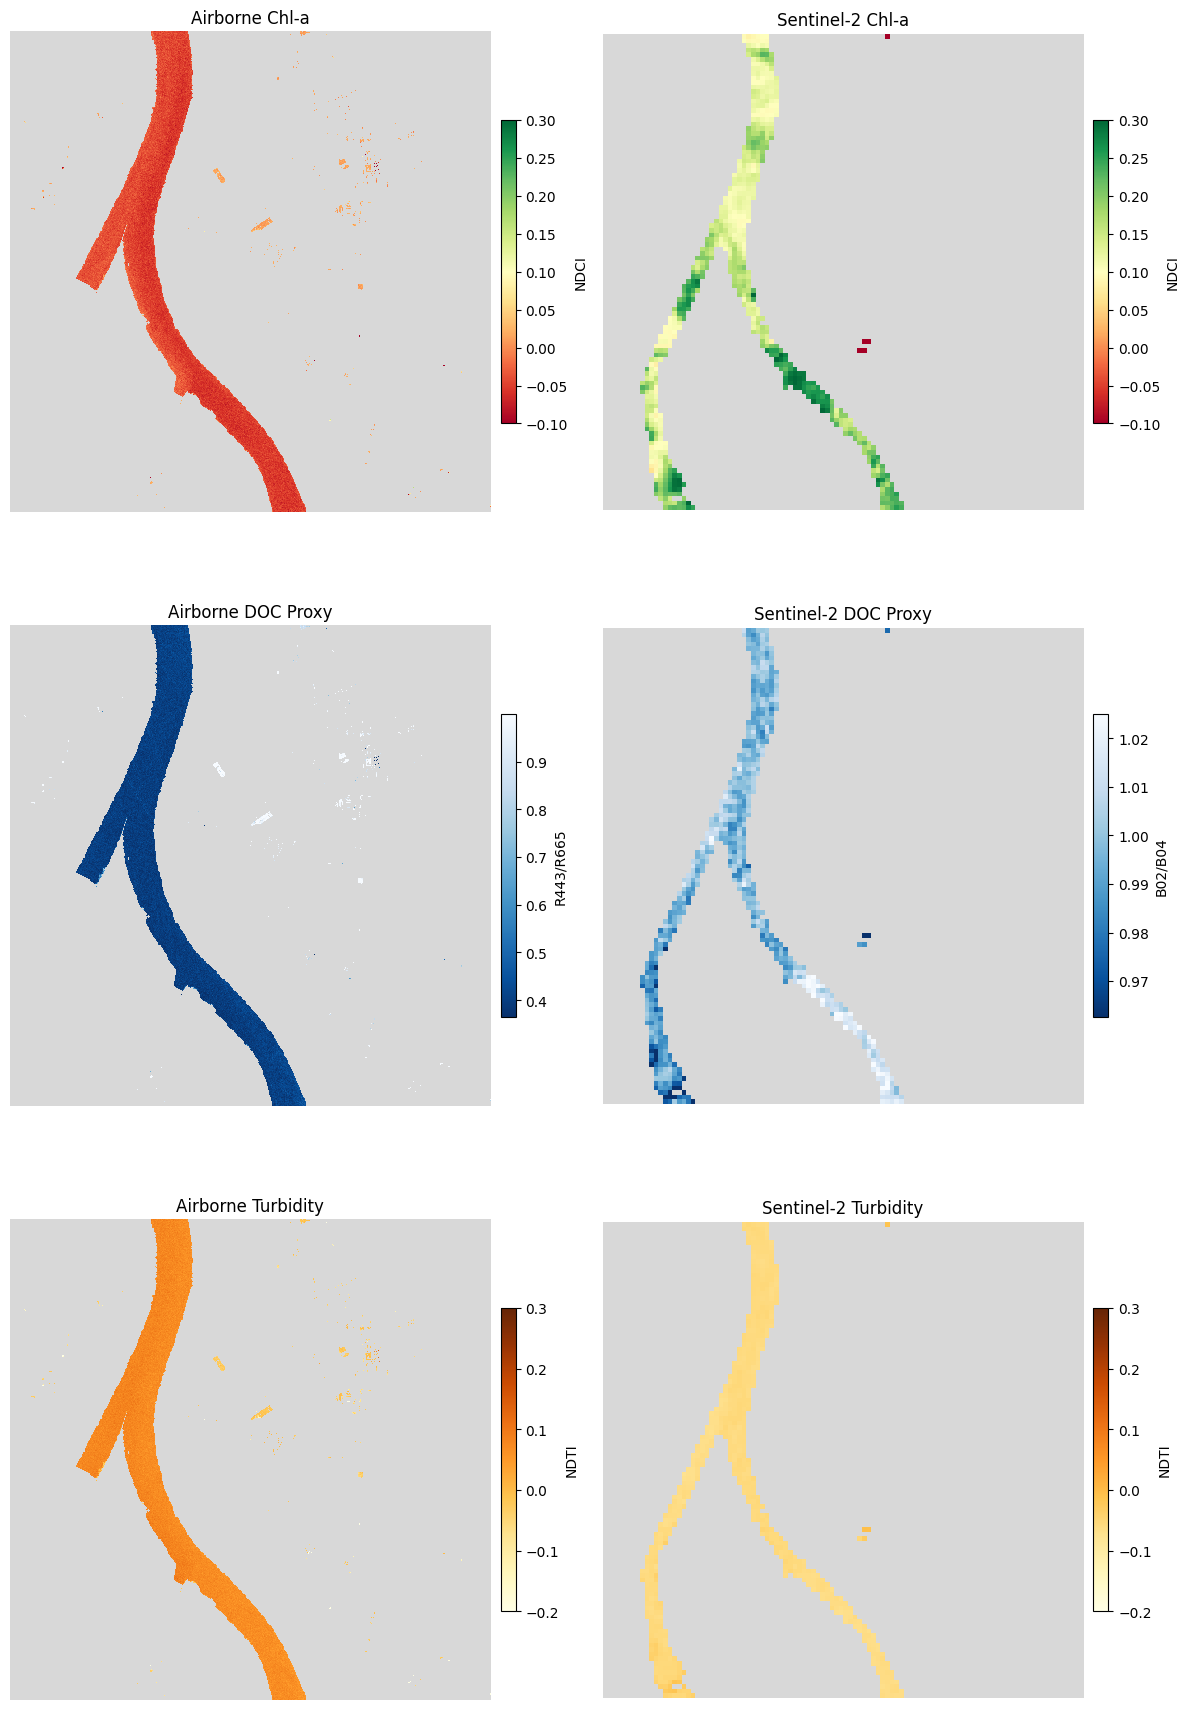

In [55]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

# Chl-a
plot_index(axes[0, 0], chla_air, water_mask, "Airborne Chl-a", 'RdYlGn', -0.1, 0.3, 'NDCI')
plot_index(axes[0, 1], chla_s2, s2_water_mask, "Sentinel-2 Chl-a", 'RdYlGn', -0.1, 0.3, 'NDCI')

# CDOM/DOC
plot_index(axes[1, 0], doc_air, water_mask, "Airborne DOC Proxy", 'Blues_r', clabel='R443/R665')
plot_index(axes[1, 1], doc_s2, s2_water_mask, "Sentinel-2 DOC Proxy", 'Blues_r', clabel='B02/B04')

# Turbidity
plot_index(axes[2, 0], turb_air, water_mask, "Airborne Turbidity", 'YlOrBr', -0.2, 0.3, 'NDTI')
plot_index(axes[2, 1], turb_s2, s2_water_mask, "Sentinel-2 Turbidity", 'YlOrBr', -0.2, 0.3, 'NDTI')

plt.tight_layout()
plt.show()